In [1]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import matplotlib.pyplot as plt

## Preparing Dataset

In [2]:
dataset_path = "/content/drive/MyDrive/7-7-Faces"
width = height = 224

image_data_generator = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    brightness_range=(0.8,1.2),
    validation_split=0.1
)

train_data = image_data_generator.flow_from_directory(
    dataset_path,
    target_size=(width,height),
    subset="training",
    shuffle=True,
    batch_size=32
)

validation_data = image_data_generator.flow_from_directory(
    dataset_path,
    target_size=(width,height),
    subset="validation",
    shuffle=False,
    batch_size=32
)

Found 1227 images belonging to 14 classes.
Found 131 images belonging to 14 classes.


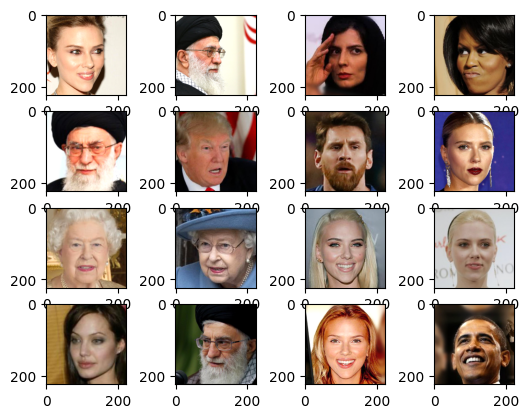

In [3]:
train_image = next(train_data)[0]

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(train_image[i])


## Create Model

In [4]:
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet", # Transfer leraning
    input_shape=(width,height,3),
    pooling="avg"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
for layer in base_model.layers[:-4]:
    layer.trainable = False

In [ ]:
base_model.summary()

In [7]:
model = Sequential([
    base_model,
    layers.Dropout(0.5),
    layers.Dense(14,activation="softmax")
])

In [ ]:
model.summary()

In [9]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=RMSprop(learning_rate=1e-4), #0.001
    metrics=["accuracy"]
)

In [10]:
history = model.fit(train_data,
                    validation_data=validation_data,
                    epochs=32)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 533s 13s/step - accuracy: 0.4002 - loss: 2.0306 - val_accuracy: 0.6031 - val_loss: 1.2653
Epoch 2/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 360ms/step - accuracy: 0.7937 - loss: 0.9083 - val_accuracy: 0.6718 - val_loss: 0.9916
Epoch 3/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 357ms/step - accuracy: 0.8939 - loss: 0.5505 - val_accuracy: 0.7252 - val_loss: 0.7876
Epoch 4/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 356ms/step - accuracy: 0.9302 - loss: 0.3725 - val_accuracy: 0.7557 - val_loss: 0.6960
Epoch 5/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 351ms/step - accuracy: 0.9559 - loss: 0.2744 - val_accuracy: 0.7481 - val_loss: 0.6535
Epoch 6/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 331ms/step - accuracy: 0.9670 - loss: 0.2013 - val_accuracy: 0.7786 - val_loss: 0.5989
Epoch 7/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 363ms/step - accuracy: 0.9821 - loss: 0.1590 - val_accuracy: 0.8244 - val_loss: 0.5339
Epoch 8/32
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 353ms/step - accuracy: 0.9943 - loss: 0.1158 - val_accur

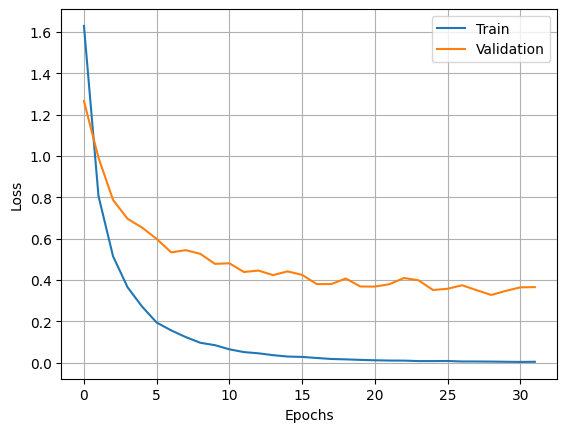

In [12]:
plt.plot(history.history["loss"],label="Train")
plt.plot(history.history["val_loss"],label="Validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

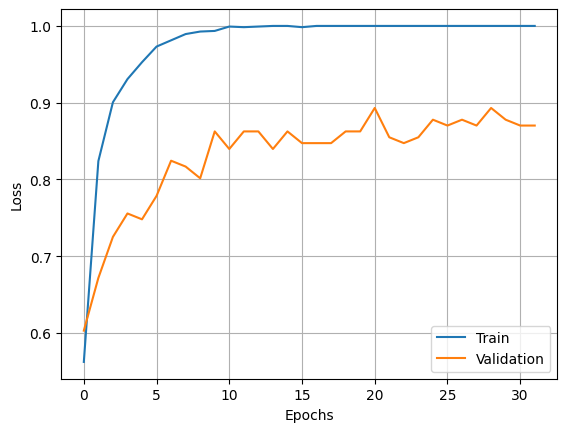

In [14]:
plt.plot(history.history["accuracy"],label="Train")
plt.plot(history.history["val_accuracy"],label="Validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [16]:
model.save("/content/drive/MyDrive/my_7_7_faces_model.h5")